# EfficientNet-B0 학습 (2클래스: 정상/비정상)
- A_noisy 데이터로 학습
- WeightedRandomSampler로 클래스 불균형 처리
- SpecAugment 적용
- Train/Val Loss 저장
- 최적 가중치 저장
- dropout = 0.4 ,

In [50]:
!pip install torch torchvision timm scikit-learn seaborn -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np
from pathlib import Path
import json
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_DIR   = '/content/drive/MyDrive/lung_sound/processed/A'
SPLIT_PATH = '/content/drive/MyDrive/lung_sound/processed/split_labels.json'
CKPT_DIR   = '/content/drive/MyDrive/lung_sound/best_checkpoints'
ckpt = torch.load('/content/drive/MyDrive/lung_sound/best_checkpoints/best_model.pth', map_location=device)
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)
print('경로 설정 완료!')

Mounted at /content/drive
경로 설정 완료!


In [52]:
BATCH_SIZE  = 32
LR          = 2e-4
N_EPOCHS    = 50
N_CLASSES   = 2
LABEL_NAMES = ['정상', '비정상']

print(f'배치 사이즈: {BATCH_SIZE}, LR: {LR}, 에포크: {N_EPOCHS}')

배치 사이즈: 32, LR: 0.0002, 에포크: 50


In [53]:
# SpecAugment
def spec_augment(mel, freq_mask=20, time_mask=30):
    mel = mel.copy()
    f  = np.random.randint(0, freq_mask)
    f0 = np.random.randint(0, mel.shape[0] - f)
    mel[f0:f0+f, :] = 0
    t  = np.random.randint(0, time_mask)
    t0 = np.random.randint(0, mel.shape[1] - t)
    mel[:, t0:t0+t] = 0
    return mel

# 데이터셋
class LungDataset(Dataset):
    def __init__(self, data_dir, items, augment=False):
        self.data_dir = Path(data_dir)
        self.items    = items
        self.augment  = augment

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        mel  = np.load(self.data_dir / item['file'])
        if self.augment:
            mel = spec_augment(mel)
        mel = np.stack([mel, mel, mel], axis=0)
        return torch.FloatTensor(mel), item['label']

print('데이터셋 정의 완료!')

데이터셋 정의 완료!


In [54]:
# 데이터 로드
with open(SPLIT_PATH, 'r') as f:
    split = json.load(f)

train_dataset = LungDataset(DATA_DIR, split['train'], augment=True)
val_dataset   = LungDataset(DATA_DIR, split['val'],   augment=False)
test_dataset  = LungDataset(DATA_DIR, split['test'],  augment=False)

# WeightedRandomSampler
label_counts = [0, 0]  # 2클래스
for item in split['train']:
    label_counts[item['label']] += 1

class_weights  = [1.0 / c if c > 0 else 0 for c in label_counts]
sample_weights = [class_weights[item['label']] for item in split['train']]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_dataset)}개, Val: {len(val_dataset)}개, Test: {len(test_dataset)}개')
print(f'클래스 분포: 정상 {label_counts[0]}개, 비정상 {label_counts[1]}개')

Train: 2730개, Val: 584개, Test: 587개
클래스 분포: 정상 1368개, 비정상 1362개


In [55]:
# EfficientNet-B0
model = timm.create_model('efficientnet_b0', pretrained=True,
                           num_classes=N_CLASSES, drop_rate=0.4)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

print(f'모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}')

모델 파라미터 수: 4,010,110


In [56]:
# 학습 루프
loss_log = {'train': [], 'val': []}
acc_log  = {'train': [], 'val': []}
best_val_acc = 0

for epoch in range(N_EPOCHS):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for mel, label in train_loader:
        mel, label = mel.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(mel)
        loss   = criterion(output, label)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        train_correct += (output.argmax(1) == label).sum().item()
        train_total   += label.size(0)

    # Val
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for mel, label in val_loader:
            mel, label = mel.to(device), label.to(device)
            output = model(mel)
            loss   = criterion(output, label)
            val_loss    += loss.item()
            val_correct += (output.argmax(1) == label).sum().item()
            val_total   += label.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    loss_log['train'].append(avg_train_loss)
    loss_log['val'].append(avg_val_loss)
    acc_log['train'].append(train_acc)
    acc_log['val'].append(val_acc)

    print(f'Epoch [{epoch+1}/{N_EPOCHS}] Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.1f}% | Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.1f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'val_acc': val_acc,
            'loss_log': loss_log,
            'acc_log': acc_log,
        }, f'{CKPT_DIR}/best_model_v4.pth')
        print(f'  → 최적 모델 저장! (val_acc: {val_acc:.1f}%)')

    scheduler.step()

Epoch [1/50] Train Loss: 2.9949 Acc: 54.1% | Val Loss: 2.0018 Acc: 53.6%
  → 최적 모델 저장! (val_acc: 53.6%)
Epoch [2/50] Train Loss: 1.9512 Acc: 57.4% | Val Loss: 1.5228 Acc: 54.5%
  → 최적 모델 저장! (val_acc: 54.5%)
Epoch [3/50] Train Loss: 1.3168 Acc: 61.2% | Val Loss: 1.2279 Acc: 55.0%
  → 최적 모델 저장! (val_acc: 55.0%)
Epoch [4/50] Train Loss: 1.1247 Acc: 62.1% | Val Loss: 1.1165 Acc: 57.4%
  → 최적 모델 저장! (val_acc: 57.4%)
Epoch [5/50] Train Loss: 0.9926 Acc: 62.0% | Val Loss: 0.9552 Acc: 60.3%
  → 최적 모델 저장! (val_acc: 60.3%)
Epoch [6/50] Train Loss: 0.8641 Acc: 65.4% | Val Loss: 0.9342 Acc: 57.0%
Epoch [7/50] Train Loss: 0.8327 Acc: 67.4% | Val Loss: 0.8100 Acc: 62.3%
  → 최적 모델 저장! (val_acc: 62.3%)
Epoch [8/50] Train Loss: 0.7343 Acc: 68.6% | Val Loss: 0.8409 Acc: 63.0%
  → 최적 모델 저장! (val_acc: 63.0%)
Epoch [9/50] Train Loss: 0.7097 Acc: 69.7% | Val Loss: 0.8282 Acc: 64.4%
  → 최적 모델 저장! (val_acc: 64.4%)
Epoch [10/50] Train Loss: 0.6799 Acc: 71.1% | Val Loss: 0.7962 Acc: 65.9%
  → 최적 모델 저장! (val_ac

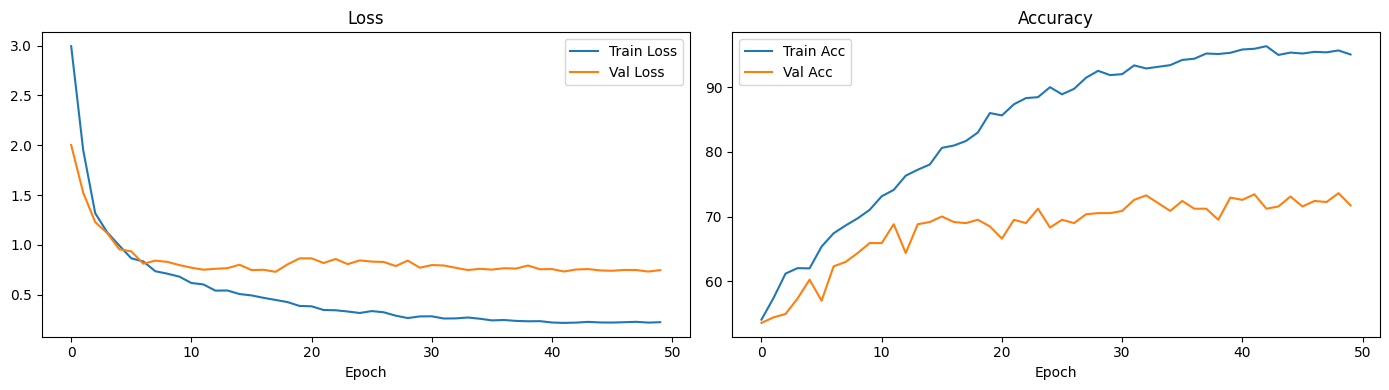

최고 Val Accuracy: 73.6%


In [66]:
# Loss & Accuracy 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_log['train'], label='Train Loss')
axes[0].plot(loss_log['val'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(acc_log['train'], label='Train Acc')
axes[1].plot(acc_log['val'],   label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'최고 Val Accuracy: {best_val_acc:.1f}%')

In [67]:
# Test 평가
ckpt = torch.load(f'{CKPT_DIR}/best_model_v4.pth', map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()

all_preds, all_labels_list, all_probs = [], [], []
with torch.no_grad():
    for mel, label in test_loader:
        mel    = mel.to(device)
        output = model(mel)
        probs  = torch.softmax(output, dim=1)
        preds  = output.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(label.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels_list)) * 100
print(f'Test Accuracy: {test_acc:.1f}%')
print('\n분류 리포트:')
print(classification_report(all_labels_list, all_preds, target_names=LABEL_NAMES))

Test Accuracy: 73.3%

분류 리포트:
              precision    recall  f1-score   support

          정상       0.73      0.73      0.73       294
         비정상       0.73      0.73      0.73       293

    accuracy                           0.73       587
   macro avg       0.73      0.73      0.73       587
weighted avg       0.73      0.73      0.73       587



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_3035/3452170102.py:10: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/3452170102.py:10: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/3452170102.py:10: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/3452170102.py:10: UserWarning: Glyph 51228 (\N{H

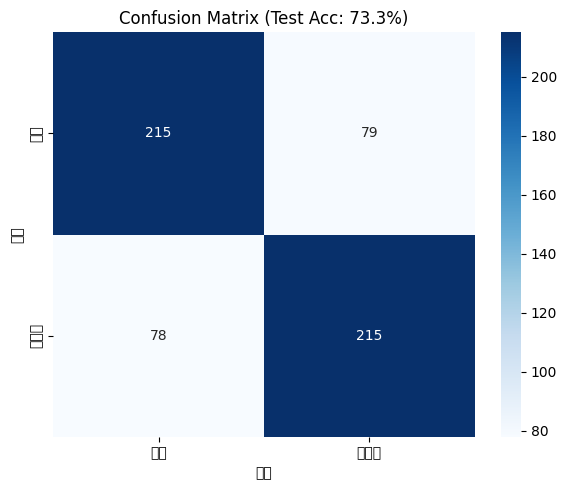


=== 샘플 예측 확률 ===
실제: 정상 | 정상 확률: 96.3% | 비정상 확률: 3.7%
실제: 정상 | 정상 확률: 98.3% | 비정상 확률: 1.7%
실제: 정상 | 정상 확률: 96.3% | 비정상 확률: 3.7%
실제: 정상 | 정상 확률: 99.5% | 비정상 확률: 0.5%
실제: 정상 | 정상 확률: 55.1% | 비정상 확률: 44.9%


In [59]:
# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title(f'Confusion Matrix (Test Acc: {test_acc:.1f}%)')
plt.ylabel('실제')
plt.xlabel('예측')
plt.tight_layout()
plt.show()

# 확률 예시 출력
print('\n=== 샘플 예측 확률 ===')
for i in range(5):
    print(f'실제: {LABEL_NAMES[all_labels_list[i]]} | 정상 확률: {all_probs[i][0]*100:.1f}% | 비정상 확률: {all_probs[i][1]*100:.1f}%')

In [60]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. 원래 71.2% 모델 학습에 썼던 데이터 경로로 설정
DATA_DIR   = '/content/drive/MyDrive/lung_sound/processed/A'  # 최초 71.2% 모델용 폴더
SPLIT_PATH = '/content/drive/MyDrive/lung_sound/processed/split_labels.json'  # 최초 split

# 2. 모델 불러오기
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2, drop_rate=0.4)
ckpt = torch.load('/content/drive/MyDrive/lung_sound/best_checkpoints/best_model.pth', map_location=device)
model.load_state_dict(ckpt['model'])
model = model.to(device)
model.eval()

# 3. test_dataset, test_loader는 이전과 동일한 방식으로 재구성
with open(SPLIT_PATH, 'r') as f:
    split = json.load(f)
test_dataset = LungDataset(DATA_DIR, split['test'], augment=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 4. 평가
all_preds, all_labels_list = [], []
with torch.no_grad():
    for mel, label in test_loader:
        mel = mel.to(device)
        output = model(mel)
        preds = output.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(label.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels_list)) * 100
print(f'Test Accuracy: {test_acc:.1f}%')
print(classification_report(all_labels_list, all_preds, target_names=['정상', '비정상']))

Test Accuracy: 75.3%
              precision    recall  f1-score   support

          정상       0.72      0.84      0.77       294
         비정상       0.80      0.67      0.73       293

    accuracy                           0.75       587
   macro avg       0.76      0.75      0.75       587
weighted avg       0.76      0.75      0.75       587



사용 디바이스: cuda
Mounted at /content/drive
불러온 체크포인트 — epoch: 47, val_acc: 71.6%
Test Accuracy: 75.3%

분류 리포트:
              precision    recall  f1-score   support

          정상       0.72      0.84      0.77       294
         비정상       0.80      0.67      0.73       293

    accuracy                           0.75       587
   macro avg       0.76      0.75      0.75       587
weighted avg       0.76      0.75      0.75       587



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_3035/1398388057.py:78: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/1398388057.py:78: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/1398388057.py:78: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/1398388057.py:78: UserWarning: Glyph 51228 (\N{H

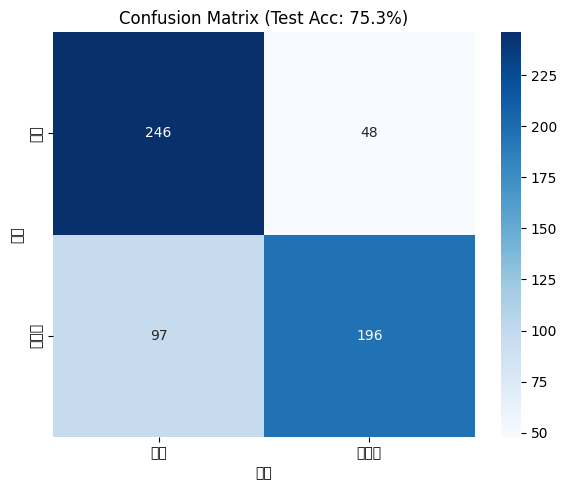

In [61]:
!pip install torch torchvision timm scikit-learn seaborn -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import json
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_DIR   = '/content/drive/MyDrive/lung_sound/processed/A'
SPLIT_PATH = '/content/drive/MyDrive/lung_sound/processed/split_labels.json'
CKPT_PATH  = '/content/drive/MyDrive/lung_sound/best_checkpoints/best_model.pth'
LABEL_NAMES = ['정상', '비정상']

# 데이터셋 클래스 (학습 때와 동일하게 정의만, augment는 안 씀)
class LungDataset(Dataset):
    def __init__(self, data_dir, items, augment=False):
        self.data_dir = Path(data_dir)
        self.items    = items
        self.augment  = augment
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        item = self.items[idx]
        mel  = np.load(self.data_dir / item['file'])
        mel = np.stack([mel, mel, mel], axis=0)
        return torch.FloatTensor(mel), item['label']

# test set만 불러옴
with open(SPLIT_PATH, 'r') as f:
    split = json.load(f)
test_dataset = LungDataset(DATA_DIR, split['test'], augment=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 모델 만들고, 학습된 가중치 불러오기 (pretrained=False! 학습 안 함)
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2, drop_rate=0.4)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model'])
model = model.to(device)
model.eval()  # 평가 모드, 학습 안 함

print(f"불러온 체크포인트 — epoch: {ckpt['epoch']}, val_acc: {ckpt['val_acc']:.1f}%")

# 평가만 (학습 루프 없음!)
all_preds, all_labels_list, all_probs = [], [], []
with torch.no_grad():
    for mel, label in test_loader:
        mel = mel.to(device)
        output = model(mel)
        probs = torch.softmax(output, dim=1)
        preds = output.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(label.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels_list)) * 100
print(f'Test Accuracy: {test_acc:.1f}%')
print('\n분류 리포트:')
print(classification_report(all_labels_list, all_preds, target_names=LABEL_NAMES))

# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title(f'Confusion Matrix (Test Acc: {test_acc:.1f}%)')
plt.ylabel('실제')
plt.xlabel('예측')
plt.tight_layout()
plt.show()

사용 디바이스: cpu
Mounted at /content/drive
불러온 체크포인트 — epoch: 48, val_acc: 73.6%
Test Accuracy: 73.3%

분류 리포트:
              precision    recall  f1-score   support

          정상       0.73      0.73      0.73       294
         비정상       0.73      0.73      0.73       293

    accuracy                           0.73       587
   macro avg       0.73      0.73      0.73       587
weighted avg       0.73      0.73      0.73       587



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_2169/2555057018.py:78: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2169/2555057018.py:78: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2169/2555057018.py:78: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2169/2555057018.py:78: UserWarning: Glyph 51228 (\N{H

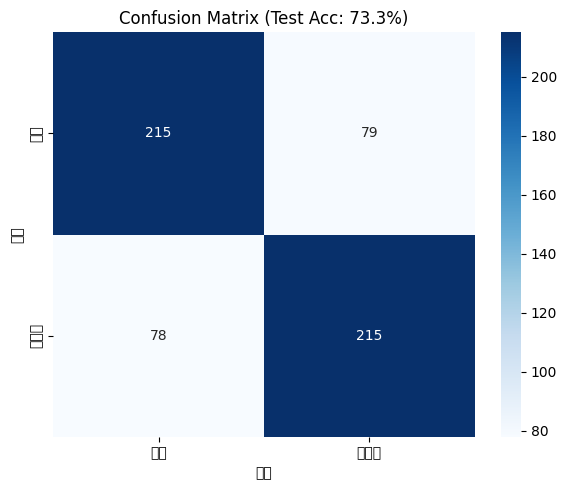

In [2]:
!pip install torch torchvision timm scikit-learn seaborn -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import json
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_DIR   = '/content/drive/MyDrive/lung_sound/processed/A'
SPLIT_PATH = '/content/drive/MyDrive/lung_sound/processed/split_labels.json'
CKPT_PATH  = '/content/drive/MyDrive/lung_sound/best_checkpoints/best_model_v4.pth'
LABEL_NAMES = ['정상', '비정상']

class LungDataset(Dataset):
    def __init__(self, data_dir, items, augment=False):
        self.data_dir = Path(data_dir)
        self.items    = items
        self.augment  = augment
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        item = self.items[idx]
        mel  = np.load(self.data_dir / item['file'])
        mel = np.stack([mel, mel, mel], axis=0)
        return torch.FloatTensor(mel), item['label']

# test set만 불러옴
with open(SPLIT_PATH, 'r') as f:
    split = json.load(f)
test_dataset = LungDataset(DATA_DIR, split['test'], augment=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 모델 만들고, 학습된 가중치 불러오기 (pretrained=False! 학습 안 함)
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2, drop_rate=0.4)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model'])
model = model.to(device)
model.eval()  # 평가 모드, 학습 안 함

print(f"불러온 체크포인트 — epoch: {ckpt['epoch']}, val_acc: {ckpt['val_acc']:.1f}%")

# 평가만 (학습 루프 없음!)
all_preds, all_labels_list, all_probs = [], [], []
with torch.no_grad():
    for mel, label in test_loader:
        mel = mel.to(device)
        output = model(mel)
        probs = torch.softmax(output, dim=1)
        preds = output.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(label.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels_list)) * 100
print(f'Test Accuracy: {test_acc:.1f}%')
print('\n분류 리포트:')
print(classification_report(all_labels_list, all_preds, target_names=LABEL_NAMES))

# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title(f'Confusion Matrix (Test Acc: {test_acc:.1f}%)')
plt.ylabel('실제')
plt.xlabel('예측')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 평가지표 1~4 한번에 계산 (위 Test 평가 셀 바로 다음에 이어 붙이기)
# 주의: 현재 모델은 정상/비정상 2클래스 모델이라
#       Wheeze/Crackle/Both를 구분하는 4클래스 confusion matrix는 계산 불가능합니다.
#       (4클래스 분류는 별도로 시도했으나 Test Accuracy 36%로 채택하지 않음)
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
files = list(Path('/content/drive/MyDrive/lung_sound/best_checkpoints').glob('*'))

import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score
import matplotlib.pyplot as plt

all_preds_arr  = np.array(all_preds)
all_labels_arr = np.array(all_labels_list)
all_probs_arr  = np.array(all_probs)   # shape: (N, 2) -> [:,0]=정상확률, [:,1]=비정상확률

# ------------------------------------------------------------
# 1. ICBHI Score = (Sensitivity + Specificity) / 2
#    여기서는 "비정상(1)"을 Positive로 두고 계산
#    주의: 이는 ICBHI 공식 60:40 split이 아닌, 본 프로젝트의 자체 split(70:15:15) 기준입니다.
# ------------------------------------------------------------
cm = confusion_matrix(all_labels_arr, all_preds_arr)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)   # = Recall(비정상) = 비정상을 비정상으로 맞춘 비율
specificity = tn / (tn + fp)   # = 정상을 정상으로 맞춘 비율
icbhi_score = (sensitivity + specificity) / 2

print('=' * 50)
print('1. ICBHI Score (자체 split 기준)')
print('=' * 50)
print(f'Sensitivity (비정상 Recall): {sensitivity:.4f}')
print(f'Specificity (정상 Recall)  : {specificity:.4f}')
print(f'ICBHI Score                : {icbhi_score:.4f}')

# ------------------------------------------------------------
# 2. Confusion Matrix 시각화 (2x2: 정상/비정상)
# ------------------------------------------------------------
print('\n' + '=' * 50)
print('2. Confusion Matrix (2-class: 정상/비정상)')
print('=' * 50)
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(LABEL_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(LABEL_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Test set)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lung_sound/confusion_matrix.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 3. 클래스별 F1-score
# ------------------------------------------------------------
f1_per_class = f1_score(all_labels_arr, all_preds_arr, average=None)
f1_macro     = f1_score(all_labels_arr, all_preds_arr, average='macro')

print('\n' + '=' * 50)
print('3. 클래스별 F1-score')
print('=' * 50)
for name, f1_val in zip(LABEL_NAMES, f1_per_class):
    print(f'{name}: {f1_val:.4f}')
print(f'Macro F1: {f1_macro:.4f}')

# ------------------------------------------------------------
# 4. ROC 커브 + AUC (비정상 클래스를 Positive로)
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(all_labels_arr, all_probs_arr[:, 1])
roc_auc = auc(fpr, tpr)

print('\n' + '=' * 50)
print('4. ROC AUC')
print('=' * 50)
print(f'AUC: {roc_auc:.4f}')

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='#1E5FCC', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve (비정상 클래스 기준)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
plt.show()

print('\n✅ 평가지표 계산 완료. confusion_matrix.png, roc_curve.png가 Drive에 저장됐습니다.')

평가 지표 출력 셀
 Mounted at /content/drive
==================================================
1. ICBHI Score (자체 split 기준)
==================================================
Sensitivity (비정상 Recall): 0.7338
Specificity (정상 Recall)  : 0.7313
ICBHI Score                : 0.7325

==================================================
2. Confusion Matrix (2-class: 정상/비정상)
==================================================
[[215  79]
 [ 78 215]]
/tmp/ipykernel_3035/2574220702.py:60: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:60: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:60: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/confusion_matrix.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/confusion_matrix.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/confusion_matrix.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:97: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)
/tmp/ipykernel_3035/2574220702.py:98: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/lung_sound/roc_curve.png', dpi=150)

==================================================
3. 클래스별 F1-score
==================================================
정상: 0.7325
비정상: 0.7325
Macro F1: 0.7325

==================================================
4. ROC AUC
==================================================
AUC: 0.8028
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

✅ 평가지표 계산 완료. confusion_matrix.png, roc_curve.png가 Drive에 저장됐습니다.
